In [6]:
import pandas as pd

# Read the Titanic dataset into a DataFrame
df = pd.read_csv('Titanic-Dataset.csv')

# Get a quick overview of the data
print("Dataset contains", df.shape[0], "rows and", df.shape[1], "columns.\n")

# Preview the first few entries
print("Here's what the first few rows look like:\n")
print(df.head())

# Check column data types and missing values
print("\nData types and missing values info:\n")
print(df.info())

# Display summary statistics for numerical features
print("\nSummary of numerical columns:\n")
print(df.describe())


Dataset contains 891 rows and 12 columns.

Here's what the first few rows look like:

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            11

In [7]:
# Remove columns that won't help with prediction (like IDs, names, and ticket info)
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df.drop(columns=columns_to_drop, axis=1, inplace=True)

# Handle missing values:
# - Fill missing ages with the median age (a common practice)
df['Age'].fillna(df['Age'].median(), inplace=True)

# - Fill missing embarkation ports with the most common value
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Convert 'Sex' from text to numbers: male = 0, female = 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Convert 'Embarked' column into dummy/indicator variables, drop first to avoid multicollinearity
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)


/var/folders/7h/7bbxj8jx0svdzqwvy9pm7n440000gn/T/ipykernel_14348/1841822724.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/var/folders/7h/7bbxj8jx0svdzqwvy9pm7n440000gn/T/ipykernel_14348/1841822724.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Separate the input features and the target variable (Survived)
X = df.drop('Survived', axis=1)  # All columns except 'Survived'
y = df['Survived']               # The target we want to predict

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize the logistic regression model and train it on the training data
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Use the trained model to make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate how well the model is performing
print("Model Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred))


Model Accuracy on Test Set: 0.8100558659217877

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



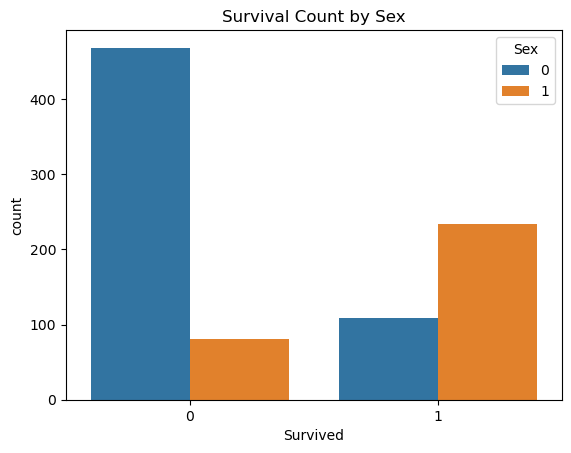

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Survived', hue='Sex')
plt.title("Survival Count by Sex")
plt.show()
